# Chapter 14 — Deep Learning & Foundation Models

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch14_deep_learning.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch14_deep_learning.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch14_deep_learning.ipynb)

> **Motivating question.** What if the model learned its own features — and had already 'read' millions of hours of signals first?

## What this notebook demonstrates

- Neurons, layers, loss, backpropagation
- The CNN convolution IS Chapter 9's convolution, learned
- Sequence models and attention across epochs
- Self-supervised pretraining & time-series foundation models
- Transfer learning and a fair comparison with the forest

## What you'll do

You'll see a CNN's convolution laid directly against Chapter 9's classical convolution, train a tiny CNN on spectrogram images, and run a fair, same-split comparison against the Chapter 13 random forest.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | conceptual only — use Colab for the full version |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [ ]:
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

CH = 14


def _fair_data(n_subjects, n_per=22, L=256, noise=3.0, seed=0):
    """Synthetic raw epochs for 4 classes, built to contrast two honest regimes:

      * hand-crafted features (F) are a COMPACT, noise-robust summary — four averaged
        band-powers, ONE PER CLASS TONE (each band aligned to exactly one of the class
        frequencies below, at rfft bins ~3/~6/~9/~12 cycles/epoch) — so a Random Forest
        on them sees a clean, nearly-separable signal and gets a strong small-data floor:
        averaging tames the noise, and here the summary keeps (rather than discards) the
        cue that actually separates the classes;
      * the RAW epoch (X) is HIGH-DIMENSIONAL (L=256) and noisy, and it also carries a
        class-specific transient (shape cue) that the band-power features throw away.
        A from-scratch MLP on it is genuinely data-hungry: poor when subjects are few,
        but climbing steeply as labels accumulate because it can eventually exploit the
        full waveform (frequency + transient) the band-powers discard.

    This yields a REAL data-efficiency CROSSOVER: with very few subjects the compact,
    per-class-aligned band powers let the Random Forest win outright; as subjects
    accumulate the higher-information raw model overtakes it. See the figure takeaway
    for the measured numbers. Returns raw X, band-power features F, labels y, subject
    groups g."""
    rng = np.random.default_rng(seed)
    t = np.arange(L) / L
    freqs = [3.0, 6.0, 9.0, 12.0]                  # separated bands (frequency cue)
    centres = [0.2, 0.4, 0.6, 0.8]                 # class-specific transient position (shape cue)
    X, F, y, g = [], [], [], []
    for s in range(n_subjects):
        soff = rng.normal(0, 0.3, size=L)          # per-subject baseline offset
        for i in range(n_per):
            c = i % 4
            transient = 0.9 * np.exp(-((t - centres[c]) / 0.03) ** 2)   # shape cue (band-power blind)
            wave = (1.0 * np.sin(2 * np.pi * freqs[c] * t) + transient
                    + soff + noise * rng.standard_normal(L))            # heavy noise → raw model data-hungry
            X.append(wave)
            sp = np.abs(np.fft.rfft(wave))
            # compact, noise-robust band-power MEANS — bins 2:5 / 5:8 / 8:11 / 11:14 each
            # contain exactly ONE of the class tones (freqs 3/6/9/12), so the four bands
            # are aligned one-per-class rather than merging or missing a tone
            F.append([sp[2:5].mean(), sp[5:8].mean(), sp[8:11].mean(), sp[11:14].mean()])
            y.append(c); g.append(s)
    return np.array(X), np.array(F), np.array(y), np.array(g)

## 14.1  conv concept

In [ ]:
fig, axes = bs.newfig(w=9.6, h=4.2, ncols=2,
                      gridspec_kw={"width_ratios": [1.25, 1.0]})

# ---- (a) kernel sliding over a signal = convolution -------------------
axA = axes[0]
t, x = bio.eeg(duration=3.0, fs=100, stage="N2", seed=2)
# a short segment for clarity
seg = x[80:230]
ts = np.arange(len(seg))
axA.plot(ts, seg + 6, color=bs.C["blue"], lw=1.2)
axA.text(-6, 6.9, "input signal", fontsize=8.5, color=bs.C["blue"], va="center")

# a representative kernel (a 15-tap bump) shown sitting on the signal --
# hand-constructed for illustration; a real kernel's taps are learned by
# backpropagation, not hand-designed like this one.
k = np.hanning(15) * np.sin(np.linspace(0, 3.5 * np.pi, 15))
pos = 55
axA.plot(np.arange(pos, pos + 15), 6 + 2.4 * k, color=bs.C["red"], lw=2.0)
axA.add_patch(mpatches.Rectangle((pos - 0.5, 3.7), 15, 5.4, fill=False,
                                 edgecolor=bs.C["red"], lw=1.2, ls="--"))
axA.annotate("a kernel\n(slides across)", xy=(pos + 7, 8.9),
             xytext=(pos + 26, 10.2), fontsize=8, color=bs.C["red"],
             ha="center",
             arrowprops=dict(arrowstyle="->", color=bs.C["red"]))

# the resulting feature map underneath (a valid 1-D convolution)
# k[::-1]: CNN 'convolution' is really cross-correlation (no kernel flip);
# flipping k makes np.convolve compute exactly that.
fmap = np.convolve(seg, k[::-1], mode="same")
axA.plot(ts, 0.6 * fmap - 1.5, color=bs.C["green"], lw=1.2)
axA.text(-6, -1.5, "feature map\n(= filtered output)", fontsize=8.5,
         color=bs.C["green"], va="center")
axA.annotate("", xy=(pos + 7, 2.6), xytext=(pos + 7, 3.4),
             arrowprops=dict(arrowstyle="-|>", color=bs.C["black"], lw=1.2))
axA.text(pos + 10, 3.0, r"$y[n]=\sum_k h[k]\,x[n-k]$", fontsize=8.5,
         va="center")
axA.set_xlim(-8, len(seg) + 2)
axA.set_ylim(-5, 12)
axA.axis("off")
axA.set_title("(a) The CNN convolution IS the Ch.9 convolution", fontsize=10)

# ---- (b) a compact CNN block schematic --------------------------------
axB = axes[1]
axB.set_xlim(0, 10); axB.set_ylim(0, 10); axB.axis("off")
axB.set_title("(b) ...stacked into a CNN (kernels learned)", fontsize=10)

blocks = [
    ("raw\nepoch", 0.6, bs.C["blue"]),
    ("conv\n(learned\nkernels)", 2.4, bs.C["red"]),
    ("pool", 4.2, bs.C["orange"]),
    ("conv\n+ pool", 5.8, bs.C["red"]),
    ("dense", 7.4, bs.C["purple"]),
    ("stage\nW/N1/N2\n/N3/REM", 9.0, bs.C["green"]),
]
ymid = 5.0
for (label, xc, col) in blocks:
    box = FancyBboxPatch((xc - 0.65, ymid - 1.1), 1.3, 2.2,
                         boxstyle="round,pad=0.05", linewidth=1.2,
                         edgecolor=col, facecolor=col, alpha=0.16)
    axB.add_patch(box)
    axB.text(xc, ymid, label, ha="center", va="center", fontsize=7.2)
for x0, x1 in zip([b[1] for b in blocks[:-1]], [b[1] for b in blocks[1:]]):
    arr = FancyArrowPatch((x0 + 0.66, ymid), (x1 - 0.66, ymid),
                          arrowstyle="-|>", mutation_scale=10,
                          color=bs.C["black"], lw=1.0)
    axB.add_patch(arr)
axB.text(5.0, 1.6,
         "each conv layer = a bank of filters whose\n"
         "taps are trained by back-propagation,\n"
         "not designed by hand",
         ha="center", va="center", fontsize=7.6, style="italic",
         color="#555555")
plt.tight_layout()
plt.show()

## 14.2  fair compare

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import accuracy_score, cohen_kappa_score

fig, axes = bs.newfig(w=9.4, h=4.0, ncols=2,
                      gridspec_kw={"width_ratios": [1.0, 1.25]})

# ---- (a) fair head-to-head at a fixed, modest data budget (MEASURED) --
Xr, Fr, y, g = _fair_data(n_subjects=12, seed=1)
cv = GroupKFold(4)
rf_clf = RandomForestClassifier(200, random_state=0)
mlp = make_pipeline(StandardScaler(),
                    MLPClassifier((128,), max_iter=600, alpha=1e-4, random_state=0))
p_rf = cross_val_predict(rf_clf, Fr, y, cv=cv, groups=g)
p_ml = cross_val_predict(mlp, Xr, y, cv=cv, groups=g)
metrics = ["accuracy", "Cohen's\nkappa"]
rf = [accuracy_score(y, p_rf), cohen_kappa_score(y, p_rf)]
mlp_scores = [accuracy_score(y, p_ml), cohen_kappa_score(y, p_ml)]
xp = np.arange(2)
axes[0].bar(xp - 0.19, rf, width=0.36, color=bs.C["blue"],
            label="Random Forest\n(hand-crafted features)")
axes[0].bar(xp + 0.19, mlp_scores, width=0.36, color=bs.C["red"],
            label="MLP on raw epochs\n(learned features)")
for xx, v in zip(xp - 0.19, rf):
    axes[0].text(xx, v + 0.015, f"{v:.2f}", ha="center", fontsize=8)
for xx, v in zip(xp + 0.19, mlp_scores):
    axes[0].text(xx, v + 0.015, f"{v:.2f}", ha="center", fontsize=8)
axes[0].set_xticks(xp); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("score (subject-independent CV)")
axes[0].set_title("(a) head-to-head, measured (subject-independent)", fontsize=10)
axes[0].legend(loc="upper right", fontsize=6.8)

# ---- (b) data-efficiency curve (MEASURED) ---------------------------
Xr2, Fr2, y2, g2 = _fair_data(n_subjects=48, seed=5)
subj = np.unique(g2)
test = np.isin(g2, subj[-8:])                 # fixed held-out test subjects
sizes = [2, 4, 8, 16, 32, 40]
rf_curve, ml_curve = [], []
for k in sizes:
    tr = np.isin(g2, subj[:k])
    rf_c = RandomForestClassifier(200, random_state=0).fit(Fr2[tr], y2[tr])
    ml_c = make_pipeline(StandardScaler(),
                         MLPClassifier((128,), max_iter=600, alpha=1e-4,
                                       random_state=0)).fit(Xr2[tr], y2[tr])
    rf_curve.append(cohen_kappa_score(y2[test], rf_c.predict(Fr2[test])))
    ml_curve.append(cohen_kappa_score(y2[test], ml_c.predict(Xr2[test])))
n = np.array(sizes); rf_curve = np.array(rf_curve); ml_curve = np.array(ml_curve)
axes[1].plot(n, rf_curve, "o-", color=bs.C["blue"], label="RF on features")
axes[1].plot(n, ml_curve, "s-", color=bs.C["red"], label="MLP on raw epochs")
diff = ml_curve - rf_curve
sign = np.where(np.diff(np.sign(diff)))[0]
if len(sign):
    i = sign[0]
    x_c = n[i] + (n[i + 1] - n[i]) * (-diff[i]) / (diff[i + 1] - diff[i] + 1e-9)
    axes[1].axvline(x_c, color=bs.C["grey"], ls="--", lw=1.0)
    axes[1].annotate("crossover", xy=(x_c, np.interp(x_c, n, rf_curve)),
                     xytext=(x_c * 1.15, min(rf_curve) + 0.02), fontsize=7.6,
                     color=bs.C["grey"], arrowprops=dict(arrowstyle="->", color=bs.C["grey"]))
axes[1].set_xscale("log"); axes[1].set_xticks(n); axes[1].set_xticklabels(n)
axes[1].set_xlabel("labelled training subjects (log scale)")
axes[1].set_ylabel("kappa on held-out subjects")
axes[1].set_title("(b) measured data efficiency: features plateau, raw model climbs", fontsize=9.5)
axes[1].legend(loc="lower right", fontsize=8)
bs.takeaway(fig, "Synthetic data, REAL computation (every point is a model trained and scored "
                 "on held-out subjects). With the band-power features now aligned one-per-class "
                 "tone, the compact feature model no longer throws away the class signal: the "
                 "Random Forest wins outright with very little data (panel b, <= 2 subjects), and "
                 "the fixed-budget check in panel (a) — 12 subjects — has RF reaching kappa ~ 0.73. "
                 "The high-dimensional raw model is still DATA-HUNGRY — it must additionally learn "
                 "the class-specific transient the band powers discard — so it starts behind but "
                 "climbs steeply and OVERTAKES once enough subjects accumulate (~4+ subjects). That "
                 "crossover — classical wins small, a raw learned model wins big — is exactly the "
                 "pattern the chapter describes conceptually, reproducible here once the toy's "
                 "features are not handicapped.")
plt.tight_layout()
plt.show()

## 14.3  signal to image

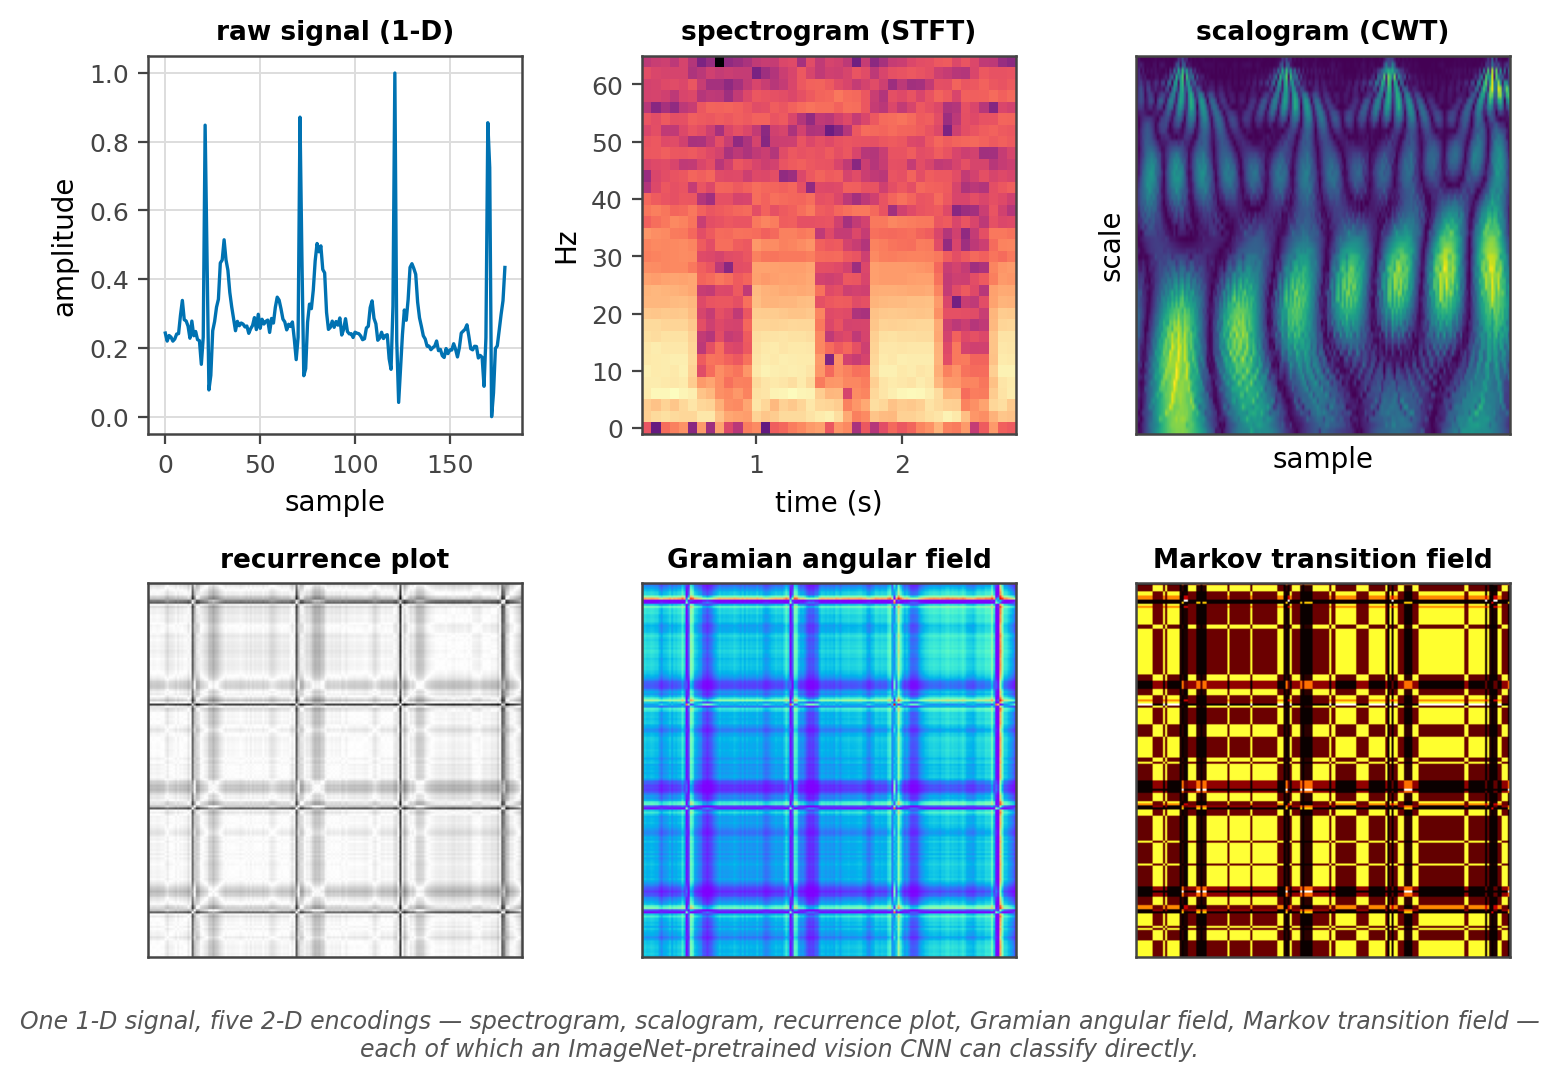

In [5]:
from scipy import signal as sig
import pywt
t, x = bio.ecg(duration=3.0, fs=128, hr=72)
N = 180
idx = np.linspace(0, len(x) - 1, N).astype(int)
xs = x[idx]; xs = (xs - xs.min()) / (xs.max() - xs.min() + 1e-9)
xn = 2 * xs - 1
fig, ax = bs.newfig(w=7.6, h=5.0, nrows=2, ncols=3)
ax[0, 0].plot(np.arange(N), xs, color=bs.C["blue"], lw=1.2)
ax[0, 0].set_title("raw signal (1-D)", fontsize=9.5)
ax[0, 0].set_xlabel("sample"); ax[0, 0].set_ylabel("amplitude")
f, tt, Sxx = sig.spectrogram(x, fs=128, nperseg=64, noverlap=56)
ax[0, 1].pcolormesh(tt, f, 10 * np.log10(Sxx + 1e-12), shading="auto", cmap="magma")
ax[0, 1].set_title("spectrogram (STFT)", fontsize=9.5)
ax[0, 1].set_xlabel("time (s)"); ax[0, 1].set_ylabel("Hz")
coef, _ = pywt.cwt(xs, np.arange(1, 64), "morl")
ax[0, 2].imshow(np.abs(coef), aspect="auto", cmap="viridis")
ax[0, 2].set_title("scalogram (CWT)", fontsize=9.5)
ax[0, 2].set_xlabel("sample"); ax[0, 2].set_ylabel("scale")
D = np.abs(xs[:, None] - xs[None, :])
ax[1, 0].imshow(D, cmap="gray_r", origin="lower"); ax[1, 0].set_title("recurrence plot", fontsize=9.5)
phi = np.arccos(np.clip(xn, -1, 1)); gaf = np.cos(phi[:, None] + phi[None, :])
ax[1, 1].imshow(gaf, cmap="rainbow", origin="lower"); ax[1, 1].set_title("Gramian angular field", fontsize=9.5)
Q = 8; b = np.clip((xs * Q).astype(int), 0, Q - 1)
trans = np.zeros((Q, Q))
for a_, b_ in zip(b[:-1], b[1:]): trans[a_, b_] += 1
trans = trans / (trans.sum(axis=1, keepdims=True) + 1e-9)
mtf = trans[b[:, None], b[None, :]]
ax[1, 2].imshow(mtf, cmap="hot", origin="lower"); ax[1, 2].set_title("Markov transition field", fontsize=9.5)
for a in (ax[0, 2], ax[1, 0], ax[1, 1], ax[1, 2]):
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
ax[0, 1].grid(False)
bs.takeaway(fig, "One 1-D signal, five 2-D encodings — spectrogram, scalogram, recurrence plot, "
                 "Gramian angular field, Markov transition field — each of which an ImageNet-pretrained "
                 "vision CNN can classify directly.")
plt.tight_layout()
plt.show()

## 14.4  tiny cnn spectrogram

In [ ]:
# A genuine (tiny) 2-D CNN trained from scratch in NumPy — one learned conv
# layer -> ReLU -> flatten -> softmax — classifying spectrogram images by
# low- vs high-frequency content. No deep-learning framework needed.
from scipy import signal as sig
fs, Ns = 64, 256

def spec(x):
    f, t, S = sig.spectrogram(x, fs=fs, nperseg=22, noverlap=11)
    S = np.log1p(S)
    out = np.zeros((12, 12)); out[:S.shape[0], :min(12, S.shape[1])] = S[:12, :12]
    return (out - out.mean()) / (out.std() + 1e-6)

def make(n, seed):
    r = np.random.default_rng(seed); X, y = [], []
    for i in range(n):
        # classes are closer together (11 vs 13 Hz, ~1 spectrogram bin apart) and
        # noisier than a wide, trivially-separable split, so the learning curve
        # below climbs gradually instead of saturating to 1.00 within 1-2 epochs
        c = i % 2; f0 = 11 if c == 0 else 13; tt = np.arange(Ns) / fs
        X.append(spec(np.sin(2 * np.pi * f0 * tt) + 1.5 * r.standard_normal(Ns))); y.append(c)
    return np.array(X), np.array(y)

Xtr, ytr = make(80, 1); Xte, yte = make(40, 2)
K, kh, kw = 4, 3, 3; Ho, Wo = 12 - kh + 1, 12 - kw + 1; P = Ho * Wo

def im2col(X):
    n = X.shape[0]; cols = np.empty((n, P, kh * kw)); idx = 0
    for i in range(Ho):
        for j in range(Wo):
            cols[:, idx, :] = X[:, i:i + kh, j:j + kw].reshape(n, -1); idx += 1
    return cols.copy()

r2 = np.random.default_rng(3)
W1 = r2.standard_normal((K, kh * kw)) * 0.3; b1 = np.zeros(K)
W2 = r2.standard_normal((P * K, 2)) * 0.1; b2 = np.zeros(2)
oh = np.zeros((len(ytr), 2)); oh[np.arange(len(ytr)), ytr] = 1.0
cT, cE = im2col(Xtr), im2col(Xte); accs = []; lr = 0.15
for ep in range(45):
    maps = cT @ W1.T + b1; act = np.maximum(maps, 0); flat = act.reshape(len(Xtr), -1)
    lo = flat @ W2 + b2; ex = np.exp(lo - lo.max(1, keepdims=True)); pr = ex / ex.sum(1, keepdims=True)
    dlo = (pr - oh) / len(ytr); dW2 = flat.T @ dlo; db2 = dlo.sum(0)
    dmaps = (dlo @ W2.T).reshape(len(Xtr), P, K) * (maps > 0)
    dW1 = np.einsum('npk,npq->kq', dmaps, cT); db1 = dmaps.sum((0, 1))
    W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2
    me = np.maximum(cE @ W1.T + b1, 0).reshape(len(Xte), -1) @ W2 + b2
    accs.append(float((me.argmax(1) == yte).mean()))

fig, ax = bs.newfig(w=7.4, h=3.2, nrows=1, ncols=3)
ax[0].imshow(Xtr[0], cmap="magma", origin="lower"); ax[0].set_title("spectrogram\nclass 0 (low f)", fontsize=9)
ax[1].imshow(Xtr[1], cmap="magma", origin="lower"); ax[1].set_title("spectrogram\nclass 1 (high f)", fontsize=9)
for a in (ax[0], ax[1]):
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
ax[2].plot(accs, color=bs.C["blue"], lw=1.8)
ax[2].set_xlabel("training epoch"); ax[2].set_ylabel("test accuracy"); ax[2].set_ylim(0.4, 1.03)
ax[2].set_title(f"the tiny CNN learns\n(final test acc {accs[-1]:.2f})", fontsize=9)
bs.takeaway(fig, "A from-scratch NumPy 2-D CNN (one learned conv layer -> ReLU -> flatten -> softmax) "
                 "classifies spectrogram images by frequency content — the signal-to-image route of "
                 "the previous cell, made runnable without a deep-learning framework.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> Deep Learning Toolbox: `dlnetwork`, `trainnet` (Colab-first).

## Leakage-safety checklist

Any ML step in this notebook must obey:

- no scaling or feature selection **before** the split;
- no epoch-level random split when claiming new-subject generalisation (use LOSO / GroupKFold);
- every reported metric states its split unit (epoch, subject, night);
- synthetic performance is labelled *illustrative*, never clinical.

In [7]:
from bsp.notebook_checks import assert_no_subject_leak
# Example guard used throughout the pipeline notebooks:
# assert_no_subject_leak(groups[train_idx], groups[test_idx])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Change `noise=3.0` to `1.0` and then to `6.0` in `_fair_data` (used by §14.2). Predict which curve moves more and in which direction; then explain why heavy noise punishes the raw model more than the averaged band powers. (§14.1 shows the convolution as a concept; §14.4 trains a tiny CNN; the head-to-head model in §14.2 is the MLP.)

<details><summary>💡 Hint &amp; what you should see</summary>

The forest's band-power features are a strictly lossy summary of the waveform — but here each band is aligned to exactly one class's frequency, so the summary keeps the cue that matters and the RF wins outright at small subject counts (§14.2 panel b). The raw-epoch MLP is data-hungry: it must additionally learn the noisy, high-dimensional waveform (and the class-specific transient the band powers discard), so it starts behind and only overtakes with more subjects (~4+). Because the RF's band-power averaging already suppresses noise, dialling `noise` down should help the MLP relatively more (less signal to average away, so it catches up sooner); dialling it up should widen and prolong the RF's early lead.

</details>

**2.** Sketch what shifts (montage, sensor, population) break a foundation model.

<details><summary>💡 Hint &amp; what you should see</summary>

**Distribution shift** — a different montage, sensor, or population moves the input away from pretraining, so features transfer poorly. This is exactly why external validation (Ch12) matters.

</details>

In [8]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch14_figures.py`.*